In [22]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

R = "Relevent"
P = "Partially Relevant"
I = "Irrelevant"

RESULT_90DAYS_PATH = "../combined_fl_results/reportfl_90days/gpt-3.5-turbo-0125_R5_full_light.json"
RESULT_CR_PATH = "../combined_fl_results/current/gpt-3.5-turbo-0125_R5_full_light.json"

score_map = {R: 2, P: 1, I: 0}

rpi_data = {
    'Cli_1': {'rpi_list': [I, P, I], 'sims': [0.07, 0.15, 0.03]}, 
    'Cli_28': {'rpi_list': [P, I, I], 'sims': [0.28, 0.01, 0.00]},
    'Cli_30': {'rpi_list': [R, P, I], 'sims': [0.76, 0.68, 0.07]}, 
    'Codec_10': {'rpi_list': [I, I, I], 'sims': [0.03, 0.02, 0.01]}, 
    'Compress_11': {'rpi_list': [I, I, I], 'sims': [0.10, 0.34, 0.14]}, 
    'Compress_15': {'rpi_list': [I, I, I], 'sims': [0.03, 0.02, 0.01]}, 
    'Compress_2': {'rpi_list': [P, R, I], 'sims': [0.27, 0.82, 0.03]}, 
    'Compress_30': {'rpi_list': [I, I, I], 'sims': [0.03, 0.08, 0.05]}, 
    'Compress_4': {'rpi_list': [P, I, I], 'sims': [0.28, 0.10, 0.06]}, 
    'Compress_46': {'rpi_list': [I, P, P], 'sims': [0.05, 0.14, 0.29]}, 
    'Compress_8': {'rpi_list': [I, I, I], 'sims': [0.28, 0.10, 0.07]}, 
    'JxPath_5': {'rpi_list': [I, I, I], 'sims': [0.04, 0.08, 0.02]}, 
    'Lang_11': {'rpi_list': [P, I ,I], 'sims': [0.81, 0.04, 0.03]}, 
    'Lang_16': {'rpi_list': [I, I, I], 'sims': [0.06, 0.21, 0.05]}, 
    'Lang_24': {'rpi_list': [I, I, I], 'sims': [0.07, 0.02, 0.06]}, 
    'Lang_34': {'rpi_list': [I, I, I], 'sims': [0.31, 0.27, 0.02]}, 
    'Lang_37': {'rpi_list': [I, I ,I], 'sims': [0.24, 0.02, 0.06]}, 
    'Lang_42': {'rpi_list': [I, I, I], 'sims': [0.04, 0.02, 0.03]}, 
    'Lang_49': {'rpi_list': [I, I, I], 'sims': [0.01, 0.03, 0.00]}, 
    'Lang_58': {'rpi_list': [I, I, I], 'sims': [0.03, 0.24, 0.02]}, 
    'Lang_8': {'rpi_list': [I, I, I], 'sims': [0.06, 0.02, 0.02]}, 
    'Math_11': {'rpi_list': [I, I, I], 'sims': [0.06, 0.31, 0.03]}, 
    'Math_16': {'rpi_list': [I, I, I], 'sims': [0.43, 0.13, 0.07]}, 
    'Math_20': {'rpi_list': [I, I, I], 'sims': [0.31, 0.09, 0.07]},
    'Math_43': {'rpi_list': [I, I, I], 'sims': [0.31, 0.01, 0.05]}, 
    'Math_58': {'rpi_list': [I, P, I], 'sims': [0.10, 0.27, 0.34]}, 
    'Math_76': {'rpi_list': [I, I, I], 'sims': [0.41, 0.30, 0.15]}, 
    'Math_83': {'rpi_list': [R, I, I], 'sims': [0.91, 0.66, 0.04]},
    'Math_84': {'rpi_list': [I, I, I], 'sims': [0.03, 0.27, 0.01]}, 
    'Math_86': {'rpi_list': [I, I, I], 'sims': [0.03, 0.15, 0.18]}
}


In [23]:
def calc_acc_at_n(data, bug_name, n_rank=1):
    """
    Calculate Acc@N (Accuracy at N)
    Returns success bug count / total bug count
    """
    buggy_methods = data.get("buggy_methods", {})
    target_bug_data = buggy_methods.get(bug_name)
    if not target_bug_data:
        return 0
    
    ranks = [
        info.get("autofl_rank")
        for info in target_bug_data.values()
        if isinstance(info, dict) and info.get("autofl_rank") is not None
    ]
    
    if ranks:
        best_rank = min(ranks)
    else:
        return 0
    
    if best_rank <= n_rank:
        return 1
    return 0

def collect_results(rpi_data, path_90, path_cr):
    score_map = {R: 2, P: 1, I: 0}
    
    # Load JSON data
    with open(path_90, "r", encoding="utf-8") as f:
        data_90 = json.load(f)
    with open(path_cr, "r", encoding="utf-8") as f:
        data_cr = json.load(f)

    processed_data = []
    for bug_name, items in rpi_data.items():
        scores = [score_map[label] for label in items['rpi_list']]
        
        # Calculate individual metrics
        acc_90 = calc_acc_at_n(data_90, bug_name, n_rank=1)
        acc_cr = calc_acc_at_n(data_cr, bug_name, n_rank=1)
        
        processed_data.append({
            "bug_name": bug_name,
            "max": max(scores) if scores else 0,
            "mean": round(sum(scores) / len(scores), 3) if scores else 0,
            "90_acc1": acc_90,
            "cr_acc1": acc_cr,
            "diff": acc_90 - acc_cr
        })
    return pd.DataFrame(processed_data)

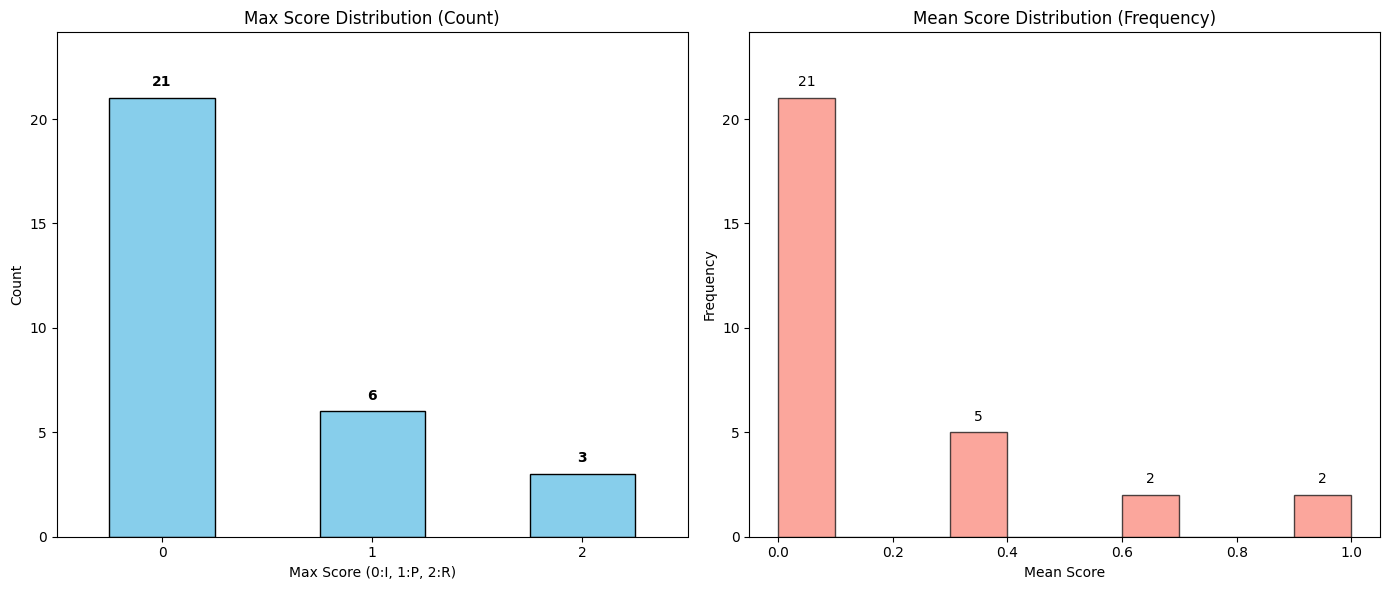

/tmp/ipykernel_1126921/1975860237.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='max', y='diff', data=df, palette="Set2")


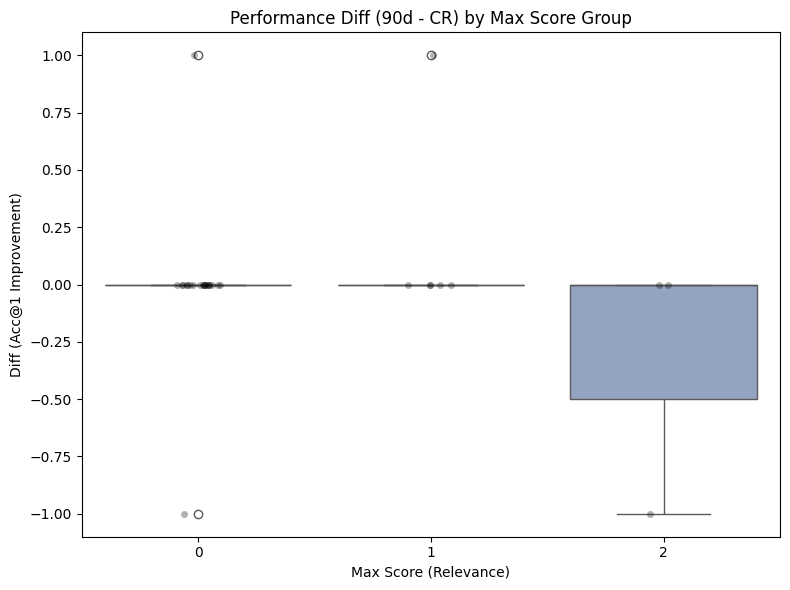

/tmp/ipykernel_1126921/1975860237.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='mean', y='diff', data=df, palette="Set2")


Spearman Correlation (Max Score vs Diff): -0.0589


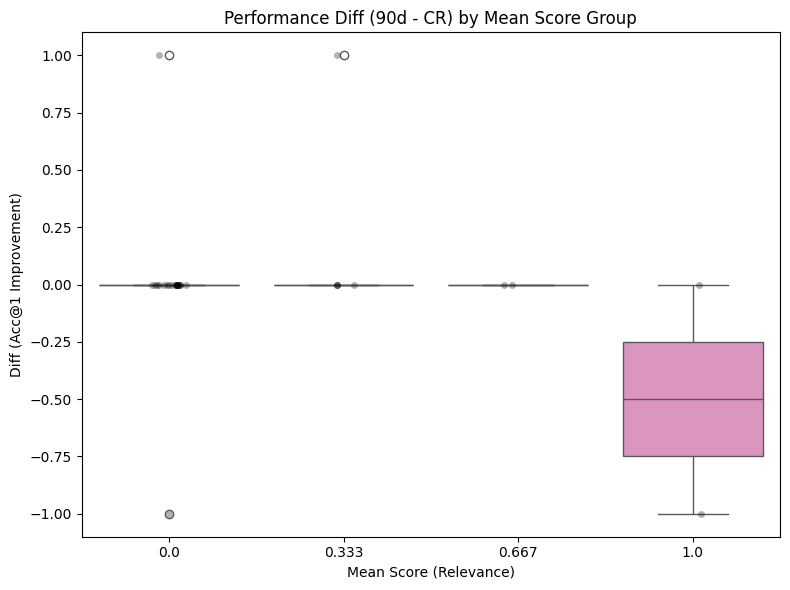

Spearman Correlation (Mean Score vs Diff): -0.0718


In [24]:
df = collect_results(rpi_data, RESULT_90DAYS_PATH, RESULT_CR_PATH)

# --- Figure 1: Relevance Score Distributions (Max & Mean) ---
plt.figure(figsize=(14, 6))

# Left: Max Score Bar Chart (with Labels)
ax1 = plt.subplot(1, 2, 1)
counts = df['max'].value_counts().sort_index()
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black', ax=ax1)
for bar in bars.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + (counts.max() * 0.02), 
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')
plt.title('Max Score Distribution (Count)')
plt.xlabel('Max Score (0:I, 1:P, 2:R)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.ylim(0, counts.max() * 1.15)

# Right: Mean Score Histogram (with Labels)
ax2 = plt.subplot(1, 2, 2)
n, bins, patches = plt.hist(df['mean'], bins=10, color='salmon', edgecolor='black', alpha=0.7)
for i in range(len(patches)):
    height = n[i]
    if height > 0:
        ax2.text(patches[i].get_x() + patches[i].get_width()/2., height + (max(n) * 0.02), 
                 f'{int(height)}', ha='center', va='bottom', fontsize=10)
plt.title('Mean Score Distribution (Frequency)')
plt.xlabel('Mean Score')
plt.ylabel('Frequency')
plt.ylim(0, max(n) * 1.15)

plt.tight_layout()
plt.show()

# --- Figure 2: Performance Analysis (Correlation, max) ---
plt.figure(figsize=(8, 6))

# Performance Diff by Max Group (Boxplot)
sns.boxplot(x='max', y='diff', data=df, palette="Set2")
sns.stripplot(x='max', y='diff', data=df, color='black', alpha=0.3)

plt.title('Performance Diff (90d - CR) by Max Score Group')
plt.xlabel('Max Score (Relevance)')
plt.ylabel('Diff (Acc@1 Improvement)')

plt.tight_layout()
plt.show()

# Correlation Summary for max
spearman_corr = df['max'].corr(df['diff'], method='spearman')
print(f"Spearman Correlation (Max Score vs Diff): {spearman_corr:.4f}")

# --- Figure 3: Performance Analysis (Correlation, mean) ---
plt.figure(figsize=(8, 6))

# Performance Diff by Max Group (Boxplot)
sns.boxplot(x='mean', y='diff', data=df, palette="Set2")
sns.stripplot(x='mean', y='diff', data=df, color='black', alpha=0.3)

plt.title('Performance Diff (90d - CR) by Mean Score Group')
plt.xlabel('Mean Score (Relevance)')
plt.ylabel('Diff (Acc@1 Improvement)')

plt.tight_layout()
plt.show()

# Correlation Summary for max
spearman_corr = df['mean'].corr(df['diff'], method='spearman')
print(f"Spearman Correlation (Mean Score vs Diff): {spearman_corr:.4f}")